## Part I: Load demo data

In [59]:
# pip install pandas pyreadstat

In [70]:
import pandas as pd
import numpy as np

# read XPT file
df_demo = pd.read_sas("../data/demo_data/DEMO_L.xpt", format="xport", encoding="utf-8")

# show top 5 rows 
df_demo.head()


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60


In [61]:
print("Demographics Data Info:")
df_demo.info() 
# 'DMDYRUSR': Length of time in US -> drop due to too many NaN

Demographics Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      11933 non-null  float64
 1   SDDSRVYR  11933 non-null  float64
 2   RIDSTATR  11933 non-null  float64
 3   RIAGENDR  11933 non-null  float64
 4   RIDAGEYR  11933 non-null  float64
 5   RIDAGEMN  377 non-null    float64
 6   RIDRETH1  11933 non-null  float64
 7   RIDRETH3  11933 non-null  float64
 8   RIDEXMON  8860 non-null   float64
 9   RIDEXAGM  2787 non-null   float64
 10  DMQMILIZ  8301 non-null   float64
 11  DMDBORN4  11914 non-null  float64
 12  DMDYRUSR  1875 non-null   float64
 13  DMDEDUC2  7794 non-null   float64
 14  DMDMARTZ  7792 non-null   float64
 15  RIDEXPRG  1503 non-null   float64
 16  DMDHHSIZ  11933 non-null  float64
 17  DMDHRGND  4115 non-null   float64
 18  DMDHRAGZ  4124 non-null   float64
 19  DMDHREDZ  3746 non-null   float64
 20  DMDH

In [62]:
df_demo.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4',
       'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND',
       'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR',
       'SDMVSTRA', 'SDMVPSU', 'INDFMPIR'],
      dtype='object')

IMPORTANT: the two columns, WTINT2YR (Full sample 2-year interview weight) and WTMEC2YR (Full sample 2-year MEC exam weight), are essential survey weights.

We must keep them because:

1. Ensure Representativeness: NHANES uses a complex sampling design, not a simple random sample. These weights adjust the collected data so that our findings accurately reflect the entire U.S. non-institutionalized civilian population, rather than just the specific sample surveyed.

2. Correct Statistical Estimates: Using these weights is crucial for obtaining accurate population estimates like means, percentages, and regression coefficients. Without them, our results will be biased.

3. Valid Statistical Inference: Proper statistical analysis of complex survey data requires these weights to calculate correct standard errors and confidence intervals, allowing for valid conclusions about the broader population.

In short, these weights are indispensable for making our analysis statistically sound and generalizable to the U.S. population.


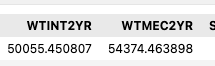

50055.450807: This value represents the Interview_Weight_2YR (full sample 2-year interview weight) for a specific participant.

This means that in statistical analyses using data collected from this participant's household interview, this individual approximately represents 50,056 people in the U.S. non-institutionalized civilian population (typically rounded or used directly as a floating-point value in calculations).

54374.463898: This value represents the Exam_Weight_2YR (full sample 2-year MEC examination weight) for the same participant.

This means that in statistical analyses using data from this participant's physical examinations or laboratory tests conducted at the Mobile Examination Center (MEC), this individual approximately represents 54,374 people in the U.S. non-institutionalized civilian population who completed MEC examinations.



In [63]:
# Select and rename essential columns
    # We'll keep SEQN for merging
    # We'll select key demographics, socioeconomic indicators, survey weights, AND interview/exam status

columns_to_keep_and_rename = {
    'SEQN': 'Participant_ID',                   # Respondent sequence number (for merging)
    'RIDSTATR': 'Interview_Exam_Status',         # Interview/Examination status (1=Interviewed only, 2=Both)
    'RIDAGEYR': 'Age_Years',                     # Age in years at screening # @Susanna, should we consider people with 80+ years old??? because Individuals 80 and over are top-coded at 80 years of age.
    'RIAGENDR': 'Gender',                        # Gender
    'RIDRETH3': 'Race_Ethnicity',                # Race/Hispanic origin w/ NH Asian (more detailed)
    'DMDEDUC2': 'Education_Level_Adults',        # Education level - Adults 20+
    'INDFMPIR': 'Income_Poverty_Ratio',          # Ratio of family income to poverty  
    'DMDMARTZ': 'Marital_Status',                # Marital status
    'DMDBORN4': 'Country_of_Birth',              # Country of birth (as a potential factor)
    'DMDHHSIZ': 'Household_Size',                # Total number of people in the Household
    'RIDEXPRG': 'Pregnancy_Status',              # Pregnancy status at exam (important for females)
    'WTINT2YR': 'Interview_Weight',              # Full sample 2-year interview weight
    'WTMEC2YR': 'Exam_Weight'                    # Full sample 2-year MEC exam weight
}

df_demo_selected = df_demo[list(columns_to_keep_and_rename.keys())].copy() # list(...) transfers dicts into lists, which then can be worked in dataframe. 
df_demo_selected.rename(columns=columns_to_keep_and_rename, inplace=True) # 

print("--- Selected and Renamed Demographics Data Info ---")
df_demo_selected.info()

--- Selected and Renamed Demographics Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Participant_ID          11933 non-null  float64
 1   Interview_Exam_Status   11933 non-null  float64
 2   Age_Years               11933 non-null  float64
 3   Gender                  11933 non-null  float64
 4   Race_Ethnicity          11933 non-null  float64
 5   Education_Level_Adults  7794 non-null   float64
 6   Income_Poverty_Ratio    9892 non-null   float64
 7   Marital_Status          7792 non-null   float64
 8   Country_of_Birth        11914 non-null  float64
 9   Household_Size          11933 non-null  float64
 10  Pregnancy_Status        1503 non-null   float64
 11  Interview_Weight        11933 non-null  float64
 12  Exam_Weight             11933 non-null  float64
dtypes: float64(13)
memory usage: 1.2 MB


In [83]:
columns_to_keep_and_rename.keys()

dict_keys(['SEQN', 'RIDSTATR', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'DMDMARTZ', 'DMDBORN4', 'DMDHHSIZ', 'RIDEXPRG', 'WTINT2YR', 'WTMEC2YR'])

In [82]:
list(columns_to_keep_and_rename.keys())

['SEQN',
 'RIDSTATR',
 'RIDAGEYR',
 'RIAGENDR',
 'RIDRETH3',
 'DMDEDUC2',
 'INDFMPIR',
 'DMDMARTZ',
 'DMDBORN4',
 'DMDHHSIZ',
 'RIDEXPRG',
 'WTINT2YR',
 'WTMEC2YR']

In [64]:
print("\n--- First 5 rows of Selected Demographics Data ---")
df_demo_selected.head()
# https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm#DMDBORN4
    # for detailed understanding of columns


--- First 5 rows of Selected Demographics Data ---


,Participant_ID,Interview_Exam_Status,Age_Years,Gender,Race_Ethnicity,Education_Level_Adults,Income_Poverty_Ratio,Marital_Status,Country_of_Birth,Household_Size,Pregnancy_Status,Interview_Weight,Exam_Weight
0,130378.0,2.0,43.0,1.0,6.0,5.0,5.00,1.0,2.0,4.0,NaN,50055.450807,54374.463898
1,130379.0,2.0,66.0,1.0,3.0,5.0,5.00,1.0,1.0,2.0,NaN,29087.450605,34084.721548
2,130380.0,2.0,44.0,2.0,2.0,3.0,1.41,1.0,2.0,7.0,2.0,80062.674301,81196.277992
3,130381.0,2.0,5.0,2.0,7.0,NaN,1.53,NaN,1.0,2.0,NaN,38807.268902,55698.607106
4,130382.0,2.0,2.0,1.0,3.0,NaN,3.60,NaN,1.0,4.0,NaN,30607.519774,36434.146346


In [65]:
print("\n--- Columns in Selected Demographics Data ---")
print(df_demo_selected.columns)


--- Columns in Selected Demographics Data ---
Index(['Participant_ID', 'Interview_Exam_Status', 'Age_Years', 'Gender',
       'Race_Ethnicity', 'Education_Level_Adults', 'Income_Poverty_Ratio',
       'Marital_Status', 'Country_of_Birth', 'Household_Size',
       'Pregnancy_Status', 'Interview_Weight', 'Exam_Weight'],
      dtype='object')


In [68]:
df_demo_selected = df_demo_selected.convert_dtypes() 

df_demo_selected['Age_Years'] = pd.to_numeric(df_demo_selected['Age_Years'], errors='coerce').round().astype('Int64')

df_demo_selected['Interview_Weight'] = pd.to_numeric(df_demo_selected['Interview_Weight'], errors='coerce').round().astype('Int64')
df_demo_selected['Exam_Weight'] = pd.to_numeric(df_demo_selected['Exam_Weight'], errors='coerce').round().astype('Int64')


df_demo_selected['Gender'] = df_demo_selected['Gender'].map({
    1: 'male',
    2: 'female'
})
df_demo_selected

,Participant_ID,Interview_Exam_Status,Age_Years,Gender,Race_Ethnicity,Education_Level_Adults,Income_Poverty_Ratio,Marital_Status,Country_of_Birth,Household_Size,Pregnancy_Status,Interview_Weight,Exam_Weight
0,130378,2,43,male,6,5,5.0,1,2,4,<NA>,50055,54374
1,130379,2,66,male,3,5,5.0,1,1,2,<NA>,29087,34085
2,130380,2,44,female,2,3,1.41,1,2,7,2,80063,81196
3,130381,2,5,female,7,<NA>,1.53,<NA>,1,2,<NA>,38807,55699
4,130382,2,2,male,3,<NA>,3.6,<NA>,1,4,<NA>,30608,36434
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,142306,2,9,male,2,<NA>,2.01,<NA>,1,2,<NA>,11147,13459
11929,142307,2,49,female,4,5,<NA>,3,1,5,<NA>,69420,64962
11930,142308,2,50,male,2,4,1.95,1,2,3,<NA>,32696,44368
11931,142309,2,40,male,2,4,3.11,2,1,5,<NA>,30548,46249


In [69]:
print("Demographics Data Info - cleaned:")
df_demo_selected.info() 

Demographics Data Info - cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Participant_ID          11933 non-null  Int64  
 1   Interview_Exam_Status   11933 non-null  Int64  
 2   Age_Years               11933 non-null  Int64  
 3   Gender                  11933 non-null  object 
 4   Race_Ethnicity          11933 non-null  Int64  
 5   Education_Level_Adults  7794 non-null   Int64  
 6   Income_Poverty_Ratio    9892 non-null   Float64
 7   Marital_Status          7792 non-null   Int64  
 8   Country_of_Birth        11914 non-null  Int64  
 9   Household_Size          11933 non-null  Int64  
 10  Pregnancy_Status        1503 non-null   Int64  
 11  Interview_Weight        11933 non-null  Int64  
 12  Exam_Weight             11933 non-null  Int64  
dtypes: Float64(1), Int64(11), object(1)
memory usage: 1.3+ MB

In [74]:
# export as csv
file_path = "../data/demo_data/cleaned_demographics_data.csv" 

try:
    df_demo_selected.to_csv(file_path, index=False, encoding='utf-8')
    print(f"DataFrame successfully saved to: {file_path}")
except Exception as e:
    print(f"Error saving DataFrame to CSV: {e}")

DataFrame successfully saved to: ../data/demo_data/cleaned_demographics_data.csv


In [ ]:
# Export to DataBase
from sqlalchemy import create_engine, types

In [80]:
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

# Now building the URL with the values from the .env file
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False) 

In [81]:
df_demo_selected.to_sql(name = 'demographic_data', con=engine, schema='capstone_group_3',if_exists='replace',index=False)

933

## Part II: Create most frequent used table for EDA analysis

In [88]:
# Read the datasets
df_demo_to_merge = pd.read_csv("../data/demo_data/cleaned_demographics_data.csv")
df_demo_to_merge

,Participant_ID,Interview_Exam_Status,Age_Years,Gender,Race_Ethnicity,Education_Level_Adults,Income_Poverty_Ratio,Marital_Status,Country_of_Birth,Household_Size,Pregnancy_Status,Interview_Weight,Exam_Weight
0,130378,2,43,male,6,5.0,5.00,1.0,2.0,4,NaN,50055,54374
1,130379,2,66,male,3,5.0,5.00,1.0,1.0,2,NaN,29087,34085
2,130380,2,44,female,2,3.0,1.41,1.0,2.0,7,2.0,80063,81196
3,130381,2,5,female,7,NaN,1.53,NaN,1.0,2,NaN,38807,55699
4,130382,2,2,male,3,NaN,3.60,NaN,1.0,4,NaN,30608,36434
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,142306,2,9,male,2,NaN,2.01,NaN,1.0,2,NaN,11147,13459
11929,142307,2,49,female,4,5.0,NaN,3.0,1.0,5,NaN,69420,64962
11930,142308,2,50,male,2,4.0,1.95,1.0,2.0,3,NaN,32696,44368
11931,142309,2,40,male,2,4.0,3.11,2.0,1.0,5,NaN,30548,46249


In [84]:
df_BMI_to_merge = pd.read_csv("../data/examination_data/cleaned_BMI_examination_data.csv")
df_BMI_to_merge

,Participant_ID,Gender,Weight_kg,Height_cm,BMI,Waist_Circumference_cm,Hip_Circumference_cm,BMI_Category,WHR,Abdominal_Obesity
0,130378,male,86.9,179.5,27.0,98.3,102.9,overweight,1.0,True
1,130379,male,101.8,174.2,33.5,114.7,112.4,obese,1.0,True
2,130380,female,69.4,152.9,29.7,93.5,98.0,overweight,1.0,True
3,130381,female,34.3,120.1,23.8,70.4,NaN,normal,NaN,NaN
4,130382,male,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8855,142306,male,25.3,128.0,15.4,57.7,NaN,underweight,NaN,NaN
8856,142307,female,NaN,143.8,NaN,NaN,NaN,NaN,NaN,NaN
8857,142308,male,79.3,173.3,26.4,98.4,97.7,overweight,1.0,True
8858,142309,male,81.9,179.1,25.5,96.0,103.3,overweight,0.9,True


In [85]:
df_Hypertensive_to_merge = pd.read_csv("../data/combined_blood_pressure_data.csv")
df_Hypertensive_to_merge

,Participant_ID,Systolic_BP_1,Systolic_BP_2,Systolic_BP_3,Diastolic_BP_1,Diastolic_BP_2,Diastolic_BP_3,Pulse_1,Pulse_2,Pulse_3,Systolic_BP_Avg,Diastolic_BP_Avg,Currently_Taking_BP_Meds,Hypertensive
0,130378,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,133.0,96.0,1.0,True
1,130379,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,117.0,79.0,1.0,True
2,130380,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,109.0,78.0,NaN,False
3,130386,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,115.0,74.0,NaN,False
4,130387,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,141.0,76.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7796,142306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7797,142307,127.0,132.0,131.0,75.0,73.0,72.0,71.0,70.0,67.0,130.0,73.0,NaN,True
7798,142308,106.0,106.0,112.0,65.0,69.0,74.0,58.0,61.0,69.0,108.0,69.0,NaN,False
7799,142309,127.0,125.0,128.0,81.0,82.0,81.0,80.0,79.0,83.0,127.0,81.0,NaN,True


In [ ]:
# Check for common Participant_IDs across all three datasets
demo_participants = set(df_demo_to_merge['Participant_ID']) # set(...) saves only non-duplicated rows
bmi_participants = set(df_BMI_to_merge['Participant_ID'])
hypertensive_participants = set(df_Hypertensive_to_merge['Participant_ID'])

In [91]:
# Find intersection of all three datasets
common_participants = demo_participants.intersection(bmi_participants).intersection(hypertensive_participants)
print(f"Participants in Demographics dataset: {len(demo_participants)}")
print(f"Participants in BMI dataset: {len(bmi_participants)}")
print(f"Participants in Hypertensive dataset: {len(hypertensive_participants)}")
print(f"Common participants across all three datasets: {len(common_participants)}")
print()


Participants in Demographics dataset: 11933
Participants in BMI dataset: 8860
Participants in Hypertensive dataset: 7801
Common participants across all three datasets: 7801



In [93]:
# Select required columns from each dataset
demo_columns = ['Participant_ID', 'Age_Years', 'Gender']
bmi_columns = ['Participant_ID', 'BMI', 'WHR', 'BMI_Category', 'Abdominal_Obesity']
hypertensive_columns = ['Participant_ID', 'Hypertensive']

df_demo_selected = df_demo_to_merge[demo_columns].copy()
df_bmi_selected = df_BMI_to_merge[bmi_columns].copy()
df_hypertensive_selected = df_Hypertensive_to_merge[hypertensive_columns].copy()

# Rename Age_Years to Age for clarity
df_demo_selected = df_demo_selected.rename(columns={'Age_Years': 'Age'})

In [97]:
# Merge the datasets step by step using inner join
df_temp = pd.merge(df_demo_selected, df_bmi_selected, on='Participant_ID', how='inner') # Step 1: Merge demographics with BMI data
df_merged = pd.merge(df_temp, df_hypertensive_selected, on='Participant_ID', how='inner') # Step 2: Merge with hypertensive data

# Display the merged dataset info
print("Merged Dataset Info:")
print(f"Shape: {df_merged.shape}")
print(f"Columns: {list(df_merged.columns)}")
print()


Merged Dataset Info:
Shape: (7801, 8)
Columns: ['Participant_ID', 'Age', 'Gender', 'BMI', 'WHR', 'BMI_Category', 'Abdominal_Obesity', 'Hypertensive']



In [98]:
# Reorder columns for better presentation
column_order = ['Participant_ID', 'Age', 'Gender', 'Hypertensive', 'BMI', 'WHR', 'BMI_Category', 'Abdominal_Obesity']
df_merged = df_merged[column_order]
df_merged



,Participant_ID,Age,Gender,Hypertensive,BMI,WHR,BMI_Category,Abdominal_Obesity
0,130378,43,male,True,27.0,1.0,overweight,True
1,130379,66,male,True,33.5,1.0,obese,True
2,130380,44,female,False,29.7,1.0,overweight,True
3,130386,34,male,False,30.2,1.0,obese,True
4,130387,68,female,True,42.6,0.8,obese,False
...,...,...,...,...,...,...,...,...
7796,142306,9,male,False,15.4,NaN,underweight,NaN
7797,142307,49,female,True,NaN,NaN,NaN,NaN
7798,142308,50,male,False,26.4,1.0,overweight,True
7799,142309,40,male,True,25.5,0.9,overweight,True


In [96]:
# Display summary statistics
print("Summary of merged dataset:")
print(df_merged.describe(include='all'))
print()


Summary of merged dataset:
        Participant_ID          Age  Gender Hypertensive          BMI  \
count      7801.000000  7801.000000    7801         7801  7691.000000   
unique             NaN          NaN       2            2          NaN   
top                NaN          NaN  female        False          NaN   
freq               NaN          NaN    4206         4406          NaN   
mean     136349.487117    44.828740     NaN          NaN    28.307541   
std        3449.490842    22.722662     NaN          NaN     7.749019   
min      130378.000000     8.000000     NaN          NaN    11.100000   
25%      133335.000000    23.000000     NaN          NaN    23.000000   
50%      136382.000000    47.000000     NaN          NaN    27.200000   
75%      139325.000000    65.000000     NaN          NaN    32.400000   
max      142310.000000    80.000000     NaN          NaN    74.800000   

                WHR BMI_Category Abdominal_Obesity  
count   6764.000000         7691           

In [101]:
# Display value counts for categorical variables, including NaN counts

print("Value counts for categorical variables (including missing values):")

print("\nGender distribution:")
# Add dropna=False to include NaN counts
print(df_merged['Gender'].value_counts(dropna=False))

print("\nBMI Category distribution:")
# Add dropna=False to include NaN counts
print(df_merged['BMI_Category'].value_counts(dropna=False))

print("\nAbdominal Obesity distribution:")
# Add dropna=False to include NaN counts
print(df_merged['Abdominal_Obesity'].value_counts(dropna=False))

print("\nHypertensive distribution:")
# Add dropna=False to include NaN counts
print(df_merged['Hypertensive'].value_counts(dropna=False))

Value counts for categorical variables (including missing values):

Gender distribution:
Gender
female    4206
male      3595
Name: count, dtype: int64

BMI Category distribution:
BMI_Category
obese          2697
normal         2255
overweight     2193
underweight     546
NaN             110
Name: count, dtype: int64

Abdominal Obesity distribution:
Abdominal_Obesity
True     5155
False    1609
NaN      1037
Name: count, dtype: int64

Hypertensive distribution:
Hypertensive
False    4406
True     3395
Name: count, dtype: int64


In [102]:
# Save the merged dataset
output_file = "../data/merged_demo_hypertensive_bmi_data.csv"
df_merged.to_csv(output_file, index=False)
print(f"Merged dataset saved to: {output_file}")

Merged dataset saved to: ../data/merged_demo_hypertensive_bmi_data.csv


In [103]:
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

# Now building the URL with the values from the .env file
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False) 

In [104]:
df_merged.to_sql(name = 'merged_demo_hypertensive_bmi_data', con=engine, schema='capstone_group_3',if_exists='replace',index=False)

801